In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import geopandas as gpd


In [25]:
print("==========================================")
print("1. LOADING AND CLEANING THE NRI DATA")
print("==========================================")
# Load the NRI datasets (Now correctly named state_tracts_...)
print("Loading NRI files...")
nri_ca = pd.read_csv('state_tracts_California.csv')
nri_mo = pd.read_csv('state_tracts_Missouri.csv')

# Combine into one NRI dataset
nri_df = pd.concat([nri_ca, nri_mo], ignore_index=True)

# Smart FIPS column handling for NRI (It can sometimes be FIPS or TRACTFIPS)
nri_fips_col = 'TRACTFIPS' if 'TRACTFIPS' in nri_df.columns else 'FIPS'
nri_df['JOIN_FIPS'] = nri_df[nri_fips_col].astype(str).str.zfill(11)

# Handle Missing Values in NRI (Filling numeric NAs with the median)
numeric_cols = nri_df.select_dtypes(include=[np.number]).columns
nri_df[numeric_cols] = nri_df[numeric_cols].fillna(nri_df[numeric_cols].median())


1. LOADING AND CLEANING THE NRI DATA
Loading NRI files...


C:\Users\ajthr\AppData\Local\Temp\ipykernel_24044\1164598936.py:14: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  nri_df['JOIN_FIPS'] = nri_df[nri_fips_col].astype(str).str.zfill(11)


In [26]:
# 1. LOADING AND STANDARDIZING NRI DATA
print("Loading NRI files...")
nri_ca = pd.read_csv('state_tracts_California.csv')
nri_mo = pd.read_csv('state_tracts_Missouri.csv')
nri_df = pd.concat([nri_ca, nri_mo], ignore_index=True).copy()

# Rename the NRI state column to our universal name
# Using 'STATEABBRV' as you identified
nri_df = nri_df.rename(columns={'STATEABBRV': 'STATE_ABBR'})

# Create the 11-digit FIPS for joining
nri_df['JOIN_FIPS'] = nri_df['TRACTFIPS'].astype(str).str.zfill(11)

# 2. LOADING AND STANDARDIZING SVI DATA
print("Loading SVI files...")
svi_ca = pd.read_csv('California.csv')
svi_mo = pd.read_csv('Missouri.csv')
svi_df = pd.concat([svi_ca, svi_mo], ignore_index=True).copy()

# Rename the SVI state column to our universal name
svi_df = svi_df.rename(columns={'ST_ABBR': 'STATE_ABBR'})

# Create the 11-digit FIPS for joining (usually 'FIPS' in SVI)
svi_df['JOIN_FIPS'] = svi_df['FIPS'].astype(str).str.zfill(11)

# 3. MERGING
# We only need a few columns from SVI to avoid clutter
svi_subset = svi_df[['JOIN_FIPS', 'RPL_THEMES']]
combined_df = pd.merge(nri_df, svi_subset, on='JOIN_FIPS', how='inner')

Loading NRI files...
Loading SVI files...


In [27]:
print("==========================================")
print("3. CALCULATING THE ALTERNATIVE RISK SCORE")
print("==========================================")
# We calculate Alt Risk = EAL_VALT (Total Expected Annual Loss) * SVI Percentile (RPL_THEMES)
# Note: if EAL_VALT isn't found, replace it with the specific Loss column you want to use
loss_col = 'EAL_VALT' if 'EAL_VALT' in combined_df.columns else 'EAL_SCORE'

combined_df['ALT_RISK_RAW'] = combined_df[loss_col] * combined_df['RPL_THEMES']

# Convert raw alternative risk into a percentile ranking (0 to 100) to directly compare with NRI
combined_df['ALT_RISK_SCORE'] = combined_df['ALT_RISK_RAW'].rank(pct=True) * 100

# Calculate bias: Positive means NRI overestimates relative to our method, Negative means NRI underestimates
combined_df['RISK_DIFFERENCE'] = combined_df['RISK_SCORE'] - combined_df['ALT_RISK_SCORE']

3. CALCULATING THE ALTERNATIVE RISK SCORE


In [28]:
# Table 1: Average Risk Scores by State
# We use 'STATE_ABBR' now
state_summary = combined_df.groupby('STATE_ABBR')[['RISK_SCORE', 'ALT_RISK_SCORE', 'RISK_DIFFERENCE']].mean().round(2)

print("\n--- Summary Table 1: Average Risk Scores by State ---")
print(state_summary)

# Table 2: Top 10 Counties with Highest Scoring Divergence
# NRI usually uses 'COUNTY' for the county name
county_summary = combined_df.groupby(['STATE_ABBR', 'COUNTY'])[
    ['RISK_SCORE', 'ALT_RISK_SCORE', 'RISK_DIFFERENCE']
].mean().round(2)

bias_table = county_summary.sort_values(by='RISK_DIFFERENCE', ascending=False).head(10)
print("\n--- Summary Table 2: Top 10 Counties with Highest Scoring Divergence ---")
print(bias_table)



--- Summary Table 1: Average Risk Scores by State ---
            RISK_SCORE  ALT_RISK_SCORE  RISK_DIFFERENCE
STATE_ABBR                                             
CA               71.43           50.82            20.60
MO               65.88           45.49            20.39

--- Summary Table 2: Top 10 Counties with Highest Scoring Divergence ---
                        RISK_SCORE  ALT_RISK_SCORE  RISK_DIFFERENCE
STATE_ABBR COUNTY                                                  
MO         Osage             81.45           30.75            50.70
           Andrew            66.06           23.12            42.94
           Clark             80.45           38.40            42.05
           Carroll           86.43           44.72            41.70
CA         Marin             79.00           38.05            40.95
           El Dorado         69.60           32.70            36.90
MO         Callaway          68.69           33.50            35.19
           Camden            87.95 

5. VISUALIZING THE DATA (FIGURES)


C:\Users\ajthr\AppData\Local\Temp\ipykernel_24044\128224864.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=combined_df, x='STATE_ABBR', y='RISK_DIFFERENCE', palette="Set2")


Saved scatter plot as 'Risk_Comparison_Scatter.png'


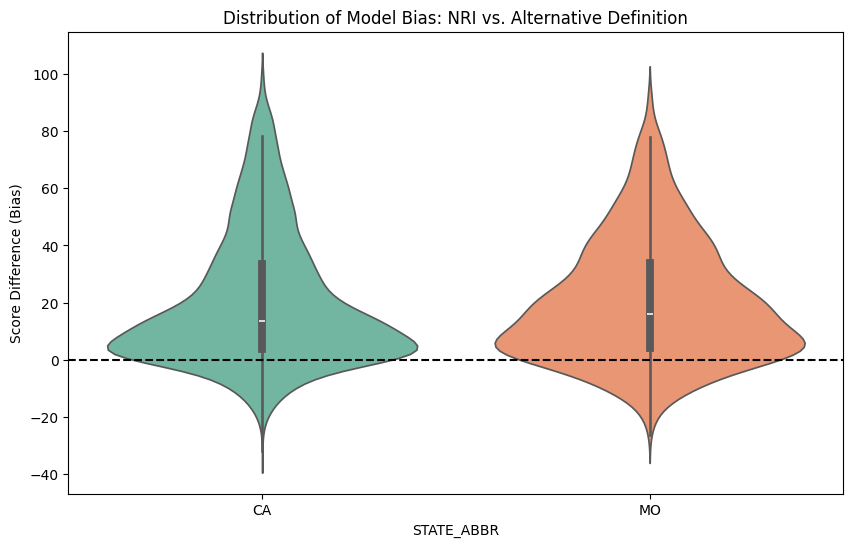

In [29]:
print("==========================================")
print("5. VISUALIZING THE DATA (FIGURES)")
print("==========================================")
plt.figure(figsize=(10, 6))
# Create the bias column if you haven't: combined_df['BIAS'] = combined_df['RISK_SCORE'] - combined_df['ALT_RISK_SCORE']
sns.violinplot(data=combined_df, x='STATE_ABBR', y='RISK_DIFFERENCE', palette="Set2")
plt.axhline(0, color='black', linestyle='--') # The "No Bias" line
plt.title('Distribution of Model Bias: NRI vs. Alternative Definition')
plt.ylabel('Score Difference (Bias)')
plt.savefig('Bias_Distribution_Violin.png')
print("Saved scatter plot as 'Risk_Comparison_Scatter.png'")


6. GENERATING THE SENSITIVITY ANALYSIS MAP
Success! Mapping 10760 tracts.


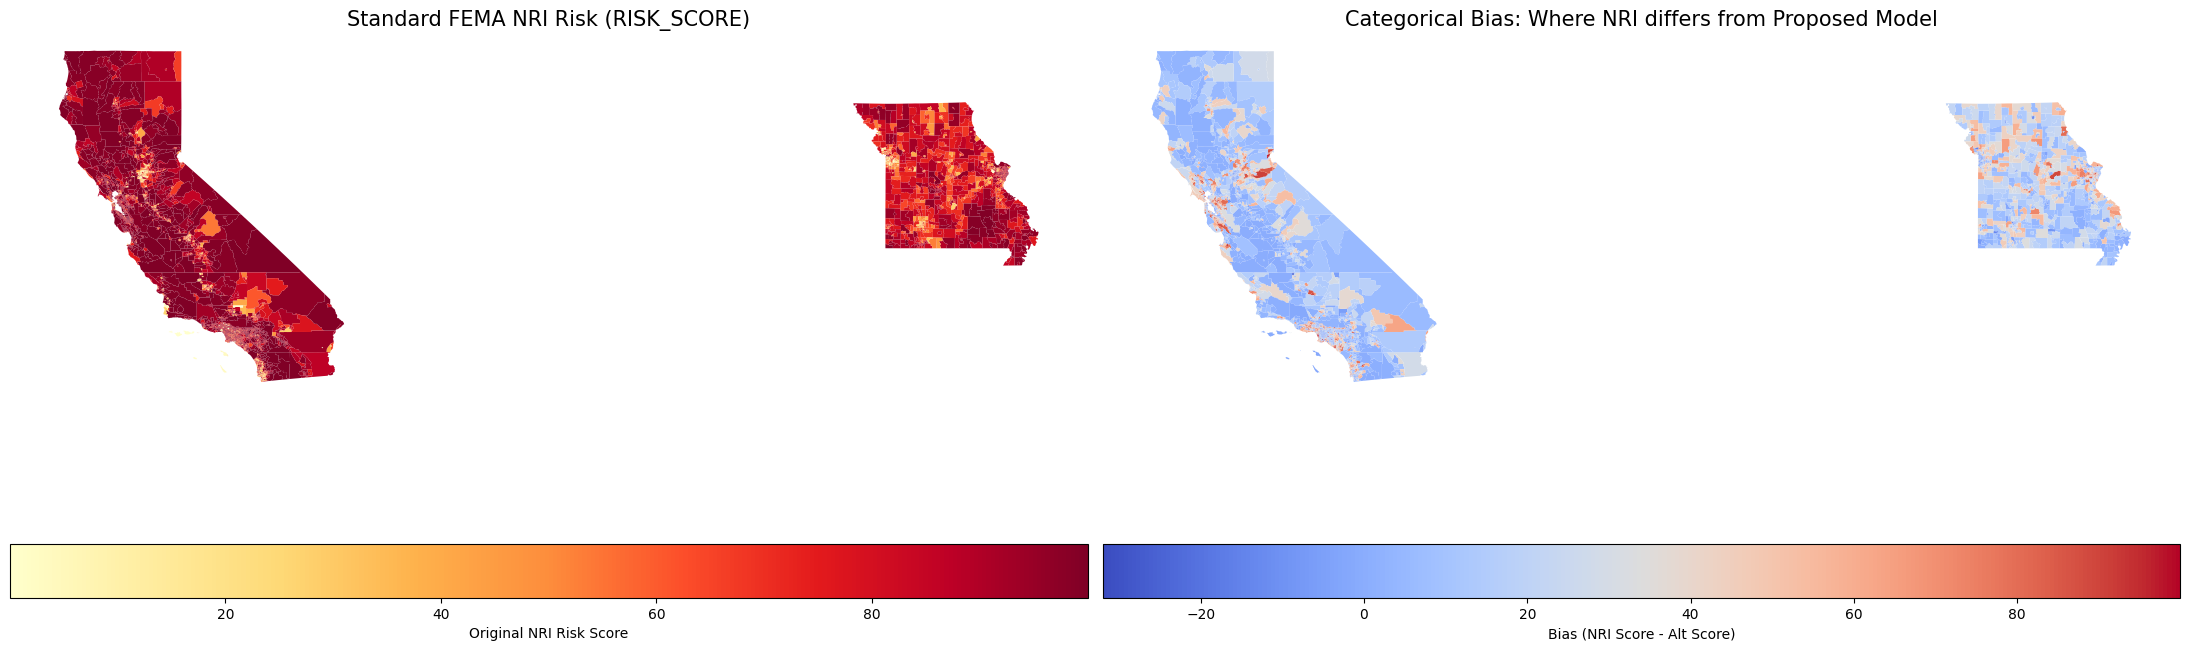

Comparison map saved successfully.


In [30]:

print("==========================================")
print("6. GENERATING THE SENSITIVITY ANALYSIS MAP")
print("==========================================")

try:
    # 1. Load the shapefile
    gdf = gpd.read_file('NRI_Shapefile_CensusTracts.shp')
    
    # 2. Filter for CA and MO and standardize the FIPS key
    gdf = gdf[gdf['STATEABBRV'].isin(['CA', 'MO'])].copy()
    gdf['JOIN_FIPS'] = gdf['TRACTFIPS'].astype(str).str.zfill(11)

    # 3. CRITICAL FIX: Drop the original NRI data columns from the shapefile 
    # so they don't clash with our analysis data columns.
    # We keep ONLY the geometry and the JOIN_FIPS.
    gdf = gdf[['geometry', 'JOIN_FIPS']]
    
    # 4. Merge with your combined_df
    # This ensures RISK_SCORE, ALT_RISK_SCORE, and RISK_DIFFERENCE come from your CSV analysis
    geo_df = gdf.merge(combined_df, on='JOIN_FIPS', how='inner')
    
    if geo_df.empty:
        print("Error: The merge resulted in an empty dataframe. Check if JOIN_FIPS values match.")
    else:
        print(f"Success! Mapping {len(geo_df)} tracts.")

        # 5. Create Side-by-Side Plots
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(22, 10))

        # Map 1: Original NRI Risk
        # Note: If 'RISK_SCORE' still fails, use 'RISK_SPCTL' which is the percentile version
        nri_col = 'RISK_SCORE' if 'RISK_SCORE' in geo_df.columns else 'RISK_SPCTL'
        
        geo_df.plot(column=nri_col, 
                    cmap='YlOrRd', 
                    legend=True, 
                    ax=ax1,
                    legend_kwds={'label': "Original NRI Risk Score", 'orientation': "horizontal"})
        ax1.set_title(f"Standard FEMA NRI Risk ({nri_col})", fontsize=15)
        ax1.set_axis_off()

        # Map 2: Your Calculated Bias
        geo_df.plot(column='RISK_DIFFERENCE', 
                    cmap='coolwarm', 
                    legend=True, 
                    ax=ax2,
                    legend_kwds={'label': "Bias (NRI Score - Alt Score)", 'orientation': "horizontal"})
        ax2.set_title("Categorical Bias: Where NRI differs from Proposed Model", fontsize=15)
        ax2.set_axis_off()

        plt.tight_layout()
        plt.savefig('Risk_Sensitivity_Comparison.png', dpi=300)
        plt.show()
        print("Comparison map saved successfully.")

except Exception as e:
    print(f"Mapping failed again. Error: {e}")